In [ ]:
#population map creation

import pandas as pd
import folium

# Load data
df = pd.read_excel("ProvincePopulation (2).xlsx")
df.columns = df.columns.str.strip().str.lower()

# folium map
m = folium.Map(location=[-30.5595, 22.9375], zoom_start=6)

# Add population circles
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['population'] / 1_000_000,
        popup=f"{row['province']}: {row['population']:,}",
        color='blue',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

# Save and open map
m.save("province_population_map.html")


# Population map creation


# Loading files and checking index


In [15]:
import pandas as pd

# Load both CSV files
crime_stats = pd.read_excel('SouthAfricaCrimeStats.xlsx')
stations_locations = pd.read_csv('geo_export_b681af05_ce59_42e8_87e6_41af282b0a6e.csv')


crime_stats = pd.read_excel('SouthAfricaCrimeStats.xlsx')
print(crime_stats.columns)

Index(['Province', 'Station', 'Longitude', 'Unnamed: 3', 'Category',
       '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010',
       '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015',
       '2015-2016'],
      dtype='object')


# Merging Data


In [25]:
# Merge on cleaned station names
merged = pd.merge(
    crime_stats,
    stations_locations[['station_clean', 'Latitude', 'Longitude']],
    on='station_clean',
    how='left',
    suffixes=('', '_from_locations')
)

# Handle longitude (has suffix due to conflict)
merged['Longitude'] = merged['Longitude'].combine_first(merged['Longitude_from_locations'])

# Latitude was added directly (no suffix), so no need to rename
# Drop temp columns
merged.drop(columns=['station_clean', 'Longitude_from_locations'], inplace=True)

# Save to new CSV
merged.to_csv('crime_stats_with_locations.csv', index=False)
print("✅ Successfully saved as 'crime_stats_with_locations.csv'")


✅ Successfully saved as 'crime_stats_with_locations.csv'


# Predictive model

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("crime_stats_with_locations.csv")

# Drop unnecessary column
df = df.drop(columns=["Unnamed: 3"])

# Melt into long format
df_melted = df.melt(
    id_vars=['Province', 'station', 'Longitude', 'Latitude', 'Category'],
    var_name='Year',
    value_name='Crime_Count'
)

# Clean up
df_melted.dropna(inplace=True)
df_melted['Year'] = df_melted['Year'].apply(lambda x: sum(map(int, x.split('-'))) / 2)

# Features and target
X = df_melted[['Province', 'station', 'Category', 'Latitude', 'Longitude', 'Year']]
y = df_melted['Crime_Count']

# Label encode categorical features
categorical_features = ['Province', 'station', 'Category']
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = GradientBoostingRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


<ipython-input-26-290351928>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
<ipython-input-26-290351928>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
<ipython-input-26-290351928>:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

RMSE: 157.32
R² Score: 0.31


# visualize the crime prediction results

In [29]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

#  Load and Preprocess Data ===
df = pd.read_csv("crime_stats_with_locations.csv")

# Drop unnecessary columns
df = df.drop(columns=["Unnamed: 3"])

# Reshape wide to long format
df_melted = df.melt(
    id_vars=['Province', 'station', 'Longitude', 'Latitude', 'Category'],
    var_name='Year',
    value_name='Crime_Count'
)

# Drop missing values and convert years
df_melted.dropna(inplace=True)
df_melted['Year'] = df_melted['Year'].apply(lambda x: sum(map(int, x.split('-'))) / 2)

# Sample 1000 rows for faster visualization
df_sampled = df_melted.sample(n=1000, random_state=42)

# Feature Engineering
X = df_sampled[['Province', 'station', 'Category', 'Latitude', 'Longitude', 'Year']]
y = df_sampled['Crime_Count']

# Encode categorical features
categorical_features = ['Province', 'station', 'Category']
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = GradientBoostingRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:\nRMSE: {rmse:.2f}\nR² Score: {r2:.2f}")

# Prepare Results for Visualization
results = X_test.copy()
results['Predicted_Crime_Count'] = y_pred
results['Actual_Crime_Count'] = y_test.values
results['station'] = label_encoders['station'].inverse_transform(results['station'])

#  Create Interactive Map
map_center = [results['Latitude'].mean(), results['Longitude'].mean()]
crime_map = folium.Map(location=map_center, zoom_start=6)
marker_cluster = MarkerCluster().add_to(crime_map)

# Color function based on prediction error
def get_color(diff):
    if diff > 100:
        return 'red'
    elif diff > 50:
        return 'orange'
    else:
        return 'green'

# Add markers
for _, row in results.iterrows():
    diff = abs(row['Predicted_Crime_Count'] - row['Actual_Crime_Count'])
    color = get_color(diff)
    popup_text = f"""
    <b>Station:</b> {row['station']}<br>
    <b>Year:</b> {row['Year']}<br>
    <b>Predicted:</b> {int(row['Predicted_Crime_Count'])}<br>
    <b>Actual:</b> {int(row['Actual_Crime_Count'])}<br>
    <b>Difference:</b> {int(diff)}
    """
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(marker_cluster)

# Save Map to HTML
crime_map.save("crime_predictions_map.html")
print("Map saved as 'crime_predictions_map.html'")


<ipython-input-29-2521027443>:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
<ipython-input-29-2521027443>:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
<ipython-input-29-2521027443>:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin

Model Performance:
RMSE: 162.14
R² Score: 0.21
Map saved as 'crime_predictions_map.html'


#  Forecast


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpk9n1lqf8/eyhdumbm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpk9n1lqf8/flfchf5b.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=76270', 'data', 'file=/tmp/tmpk9n1lqf8/eyhdumbm.json', 'init=/tmp/tmpk9n1lqf8/flfchf5b.json', 'output', 'file=/tmp/tmpk9n1lqf8/prophet_modelra82j3l0/prophet_model-20250611074044.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
07:40:44 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:40:44 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

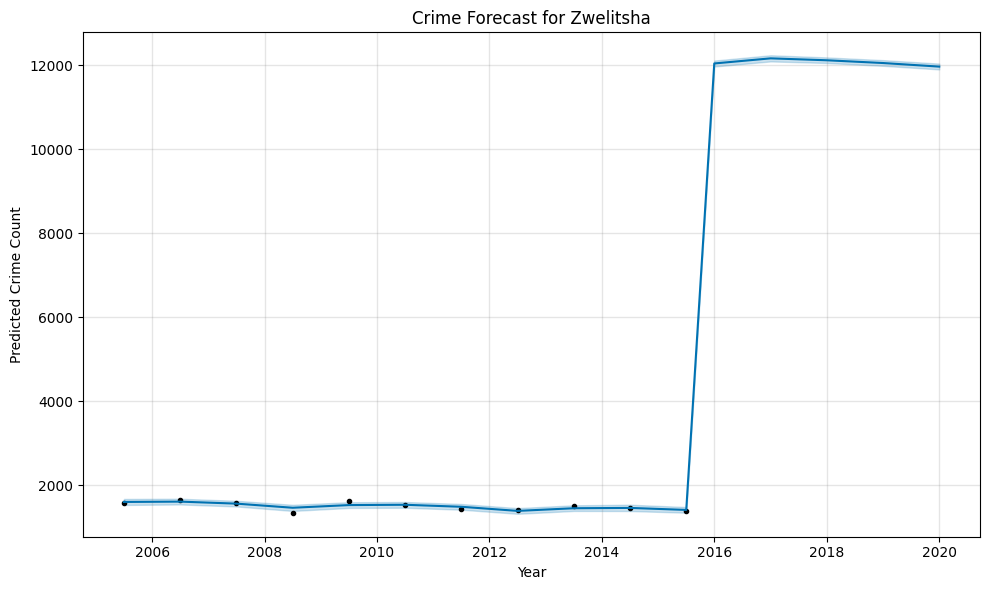

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpk9n1lqf8/tfgtrdj6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpk9n1lqf8/g5s9h67w.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=60874', 'data', 'file=/tmp/tmpk9n1lqf8/tfgtrdj6.json', 'init=/tmp/tmpk9n1lqf8/g5s9h67w.json', 'output', 'file=/tmp/tmpk9n1lqf8/prophet_modelsyhgwlm1/prophet_model-20250611074045.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
07:40:45 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:40:45 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

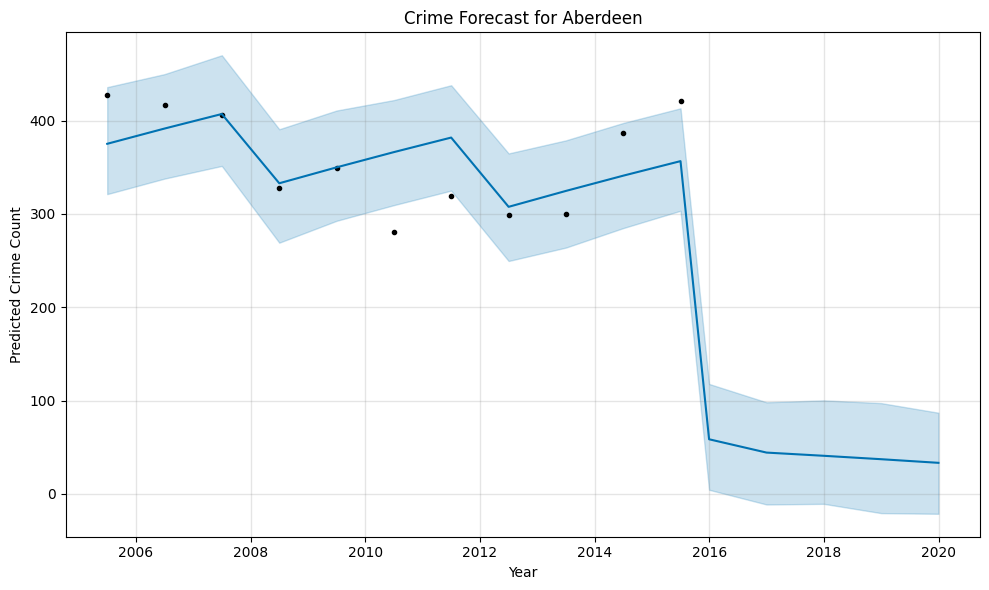

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpk9n1lqf8/gmuw8bt5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpk9n1lqf8/iq1lceau.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=50763', 'data', 'file=/tmp/tmpk9n1lqf8/gmuw8bt5.json', 'init=/tmp/tmpk9n1lqf8/iq1lceau.json', 'output', 'file=/tmp/tmpk9n1lqf8/prophet_model1dshumiz/prophet_model-20250611074045.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
07:40:45 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:40:45 - cmdstanpy - INFO - Chain [1] done processing
INFO:c

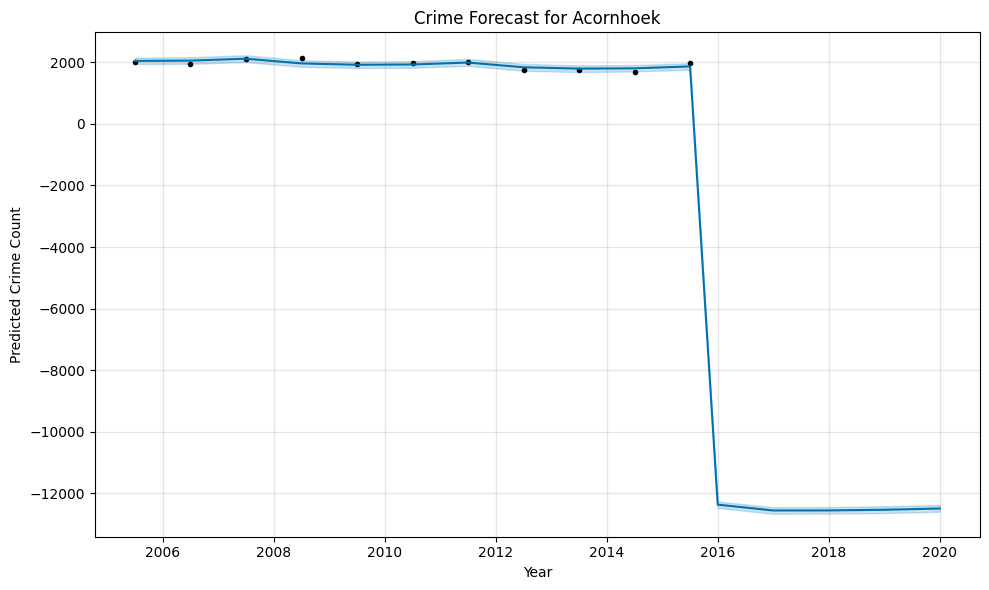

✅ Forecasts saved to 'station_crime_forecasts_corrected.csv'


In [32]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from datetime import datetime

# Load dataset
df = pd.read_csv("crime_stats_with_locations.csv")

# Drop unnamed or irrelevant columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Melt wide format into long
df_long = df.melt(
    id_vars=['Province', 'station', 'Longitude', 'Latitude', 'Category'],
    var_name='Year',
    value_name='Crime_Count'
)

df_long.dropna(subset=['Crime_Count'], inplace=True)

# Convert year range like "2017-2018" into midpoint float like 2017.5
df_long['Year'] = df_long['Year'].apply(lambda x: sum(map(int, x.split('-'))) / 2 if '-' in x else float(x))

# Convert float year to datetime
def year_fraction_to_date(year_frac):
    year = int(year_frac)
    fraction = year_frac - year
    days_in_year = 366 if pd.Timestamp(f"{year}-12-31").is_leap_year else 365
    day_of_year = int(fraction * days_in_year)
    return pd.Timestamp(f"{year}-01-01") + pd.to_timedelta(day_of_year, unit='D')

# Group by station and year
grouped = df_long.groupby(['station', 'Year'])['Crime_Count'].sum().reset_index()
grouped.columns = ['station', 'ds', 'y']
grouped['ds'] = grouped['ds'].apply(year_fraction_to_date)

# Select top 3 stations
top_stations = grouped['station'].value_counts().head(3).index.tolist()

results = []

for station in top_stations:
    station_df = grouped[grouped['station'] == station].copy()

    if station_df['ds'].nunique() < 2:
        continue

    model = Prophet(yearly_seasonality=True)
    model.fit(station_df)

    future = model.make_future_dataframe(periods=5, freq='Y')
    forecast = model.predict(future)

    model.plot(forecast)
    plt.title(f"Crime Forecast for {station}")
    plt.xlabel("Year")
    plt.ylabel("Predicted Crime Count")
    plt.tight_layout()
    plt.show()

    forecast['station'] = station
    results.append(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'station']])

# Save all results
all_forecasts = pd.concat(results)
all_forecasts.to_csv("station_crime_forecasts_corrected.csv", index=False)
print("✅ Forecasts saved to 'station_crime_forecasts_corrected.csv'")


# National trend over time analysis


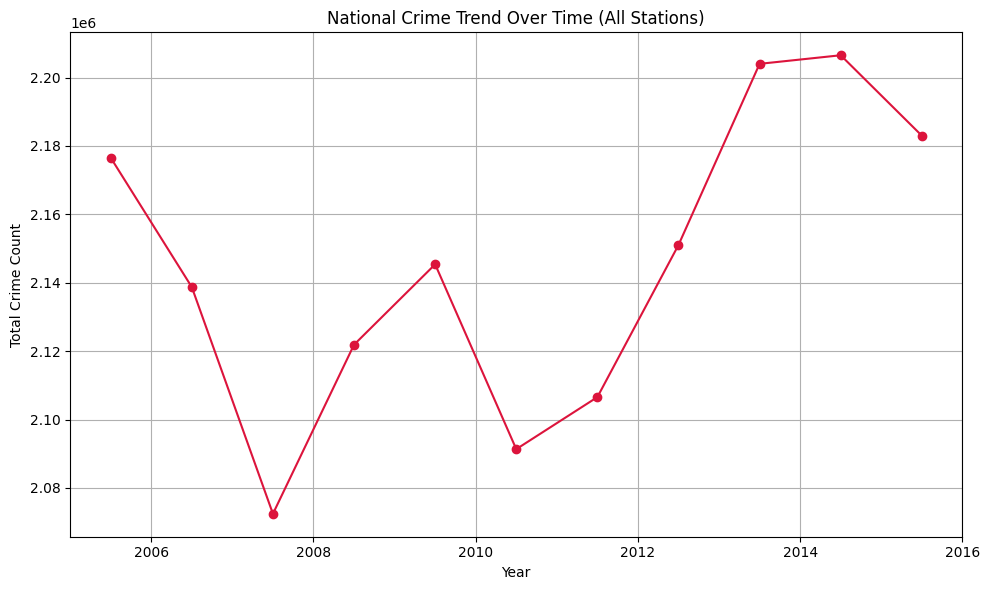

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = "crime_stats_with_locations.csv"  # Update if needed
df = pd.read_csv(file_path)

# Remove unnecessary unnamed columns (like "Unnamed: 0")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Identify year columns (e.g., '2017-2018', etc.)
year_columns = [col for col in df.columns if '-' in col]

# Convert from wide to long format
df_long = df.melt(
    id_vars=['Province', 'station', 'Latitude', 'Longitude', 'Category'],
    value_vars=year_columns,
    var_name='Year',
    value_name='Crime_Count'
)

# Convert year ranges to midpoints (e.g., 2017.5)
df_long['Year'] = df_long['Year'].str.extract(r'(\d{4})').astype(float) + 0.5

# Ensure crime count is numeric
df_long['Crime_Count'] = pd.to_numeric(df_long['Crime_Count'], errors='coerce').fillna(0)

# Group and sum by year to get national totals
national_trend = df_long.groupby('Year')['Crime_Count'].sum().reset_index()

# Plot the national trend
plt.figure(figsize=(10, 6))
plt.plot(national_trend['Year'], national_trend['Crime_Count'], marker='o', linestyle='-', color='crimson')
plt.title('National Crime Trend Over Time (All Stations)')
plt.xlabel('Year')
plt.ylabel('Total Crime Count')
plt.grid(True)
plt.tight_layout()
plt.show()
